## 1. Problem Overview

Rail corrugation is classified into three classes:

- Normal
- Side I
- Side II

Each recording contains 1 second of measurements sampled at 10,000 Hz.

The recording contains:
- 1 rotational-speed signal
- 64 axle boxes
- 2 signals per axle box: vibration and shock

The axle positions are mapped to the two rail sides:

- Side I: positions 1, 3, 5, 7
- Side II: positions 2, 4, 6, 8

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

DATA_DIR = Path("..")
TRAIN_PATH = DATA_DIR / "Train"
TEST_PATH = DATA_DIR / "Test"
LABELS_PATH = DATA_DIR / "Train_Labels.csv"

print("Train path:", TRAIN_PATH.resolve())
print("Test path:", TEST_PATH.resolve())
print("Labels:", LABELS_PATH.resolve())

print("\nFile checks:")
print("Train:", TRAIN_PATH.exists())
print("Test:", TEST_PATH.exists())
print("Labels:", LABELS_PATH.exists())

Train path: /Users/yeo/Documents/RAIL/Train
Test path: /Users/yeo/Documents/RAIL/Test
Labels: /Users/yeo/Documents/RAIL/Train_Labels.csv

File checks:
Train: True
Test: True
Labels: True


In [23]:
labels = pd.read_csv(LABELS_PATH)

print("Labels shape:", labels.shape)
display(labels.head())

Labels shape: (272, 2)


,filename,label
0,Train1.csv,Normal
1,Train2.csv,Side II
2,Train3.csv,Normal
3,Train4.csv,Normal
4,Train5.csv,Normal


In [24]:
print("Class distribution:")
display(labels["label"].value_counts())

Class distribution:


label
Normal     234
Side II     24
Side I      14
Name: count, dtype: int64

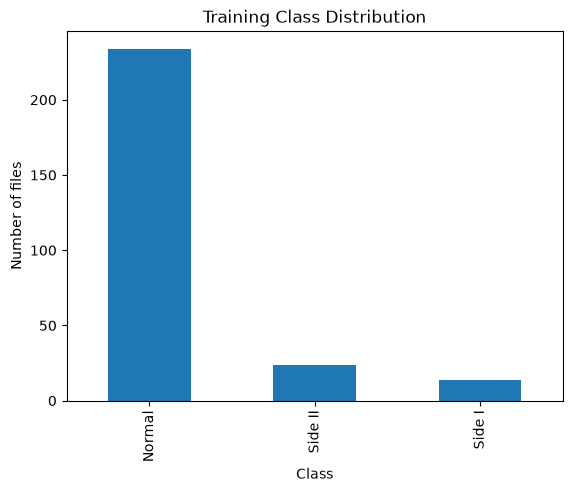

In [27]:
labels["label"].value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of files")
plt.title("Training Class Distribution")
plt.show()

In [28]:
train1 = pd.read_csv(TRAIN_PATH / "Train1.csv")
train2 = pd.read_csv(TRAIN_PATH / "Train2.csv")
train62 = pd.read_csv(TRAIN_PATH / "Train62.csv")

print("Train1:", train1.shape)
print("Train2:", train2.shape)
print("Train62:", train62.shape)

Train1: (10000, 129)
Train2: (10000, 129)
Train62: (10000, 129)


In [29]:
display(train1.head())
print("Columns:", len(train1.columns))
display(train1.columns.tolist())

,Rotating speed,Vibration of bearing in position 1 of car 1,Shock of bearing in position 1 of car 1,Vibration of bearing in position 2 of car 1,Shock of bearing in position 2 of car 1,Vibration of bearing in position 3 of car 1,Shock of bearing in position 3 of car 1,Vibration of bearing in position 4 of car 1,Shock of bearing in position 4 of car 1,Vibration of bearing in position 5 of car 1,Shock of bearing in position 5 of car 1,Vibration of bearing in position 6 of car 1,Shock of bearing in position 6 of car 1,Vibration of bearing in position 7 of car 1,Shock of bearing in position 7 of car 1,Vibration of bearing in position 8 of car 1,Shock of bearing in position 8 of car 1,Vibration of bearing in position 1 of car 2,Shock of bearing in position 1 of car 2,Vibration of bearing in position 2 of car 2,Shock of bearing in position 2 of car 2,Vibration of bearing in position 3 of car 2,Shock of bearing in position 3 of car 2,Vibration of bearing in position 4 of car 2,Shock of bearing in position 4 of car 2,Vibration of bearing in position 5 of car 2,Shock of bearing in position 5 of car 2,Vibration of bearing in position 6 of car 2,Shock of bearing in position 6 of car 2,Vibration of bearing in position 7 of car 2,Shock of bearing in position 7 of car 2,Vibration of bearing in position 8 of car 2,Shock of bearing in position 8 of car 2,Vibration of bearing in position 1 of car 3,Shock of bearing in position 1 of car 3,Vibration of bearing in position 2 of car 3,Shock of bearing in position 2 of car 3,Vibration of bearing in position 3 of car 3,Shock of bearing in position 3 of car 3,Vibration of bearing in position 4 of car 3,Shock of bearing in position 4 of car 3,Vibration of bearing in position 5 of car 3,Shock of bearing in position 5 of car 3,Vibration of bearing in position 6 of car 3,Shock of bearing in position 6 of car 3,Vibration of bearing in position 7 of car 3,Shock of bearing in position 7 of car 3,Vibration of bearing in position 8 of car 3,Shock of bearing in position 8 of car 3,Vibration of bearing in position 1 of car 4,Shock of bearing in position 1 of car 4,Vibration of bearing in position 2 of car 4,Shock of bearing in position 2 of car 4,Vibration of bearing in position 3 of car 4,Shock of bearing in position 3 of car 4,Vibration of bearing in position 4 of car 4,Shock of bearing in position 4 of car 4,Vibration of bearing in position 5 of car 4,Shock of bearing in position 5 of car 4,Vibration of bearing in position 6 of car 4,Shock of bearing in position 6 of car 4,Vibration of bearing in position 7 of car 4,Shock of bearing in position 7 of car 4,Vibration of bearing in position 8 of car 4,Shock of bearing in position 8 of car 4,Vibration of bearing in position 1 of car 5,Shock of bearing in position 1 of car 5,Vibration of bearing in position 2 of car 5,Shock of bearing in position 2 of car 5,Vibration of bearing in position 3 of car 5,Shock of bearing in position 3 of car 5,Vibration of bearing in position 4 of car 5,Shock of bearing in position 4 of car 5,Vibration of bearing in position 5 of car 5,Shock of bearing in position 5 of car 5,Vibration of bearing in position 6 of car 5,Shock of bearing in position 6 of car 5,Vibration of bearing in position 7 of car 5,Shock of bearing in position 7 of car 5,Vibration of bearing in position 8 of car 5,Shock of bearing in position 8 of car 5,Vibration of bearing in position 1 of car 6,Shock of bearing in position 1 of car 6,Vibration of bearing in position 2 of car 6,Shock of bearing in position 2 of car 6,Vibration of bearing in position 3 of car 6,Shock of bearing in position 3 of car 6,Vibration of bearing in position 4 of car 6,Shock of bearing in position 4 of car 6,Vibration of bearing in position 5 of car 6,Shock of bearing in position 5 of car 6,Vibration of bearing in position 6 of car 6,Shock of bearing in position 6 of car 6,Vibration of bearing in position 7 of car 6,Shock of bearing in position 7 of car 6,Vibration of bearing in position 8 o

Columns: 129


['Rotating speed',
 'Vibration of bearing in position 1 of car 1',
 'Shock of bearing in position 1 of car 1',
 'Vibration of bearing in position 2 of car 1',
 'Shock of bearing in position 2 of car 1',
 'Vibration of bearing in position 3 of car 1',
 'Shock of bearing in position 3 of car 1',
 'Vibration of bearing in position 4 of car 1',
 'Shock of bearing in position 4 of car 1',
 'Vibration of bearing in position 5 of car 1',
 'Shock of bearing in position 5 of car 1',
 'Vibration of bearing in position 6 of car 1',
 'Shock of bearing in position 6 of car 1',
 'Vibration of bearing in position 7 of car 1',
 'Shock of bearing in position 7 of car 1',
 'Vibration of bearing in position 8 of car 1',
 'Shock of bearing in position 8 of car 1',
 'Vibration of bearing in position 1 of car 2',
 'Shock of bearing in position 1 of car 2',
 'Vibration of bearing in position 2 of car 2',
 'Shock of bearing in position 2 of car 2',
 'Vibration of bearing in position 3 of car 2',
 'Shock of be

In [30]:
print("Data types:")
display(train1.dtypes.value_counts())

Data types:


float64    128
int64        1
Name: count, dtype: int64

In [31]:
print("Missing values:")
print("Train1:", train1.isna().sum().sum())
print("Train2:", train2.isna().sum().sum())
print("Train62:", train62.isna().sum().sum())

Missing values:
Train1: 0
Train2: 0
Train62: 0


In [33]:
speed_col = train1.columns[0]

vib_cols = [c for c in train1.columns if "vibration" in c.lower()]
shock_cols = [c for c in train1.columns if "shock" in c.lower()]

print("Speed:", speed_col)
print("Vibration channels:", len(vib_cols))
print("Shock channels:", len(shock_cols))

Speed: Rotating speed
Vibration channels: 64
Shock channels: 64


In [34]:
display(vib_cols[:8])
display(shock_cols[:8])

['Vibration of bearing in position 1 of car 1',
 'Vibration of bearing in position 2 of car 1',
 'Vibration of bearing in position 3 of car 1',
 'Vibration of bearing in position 4 of car 1',
 'Vibration of bearing in position 5 of car 1',
 'Vibration of bearing in position 6 of car 1',
 'Vibration of bearing in position 7 of car 1',
 'Vibration of bearing in position 8 of car 1']

['Shock of bearing in position 1 of car 1',
 'Shock of bearing in position 2 of car 1',
 'Shock of bearing in position 3 of car 1',
 'Shock of bearing in position 4 of car 1',
 'Shock of bearing in position 5 of car 1',
 'Shock of bearing in position 6 of car 1',
 'Shock of bearing in position 7 of car 1',
 'Shock of bearing in position 8 of car 1']

In [35]:
print("Samples per recording:", len(train1))
print("Sampling frequency: 10,000 Hz")
print("Recording duration:", len(train1) / 10000, "seconds")

Samples per recording: 10000
Sampling frequency: 10,000 Hz
Recording duration: 1.0 seconds


In [36]:
display(train1[speed_col].value_counts())

Rotating speed
0    5001
1    4999
Name: count, dtype: int64

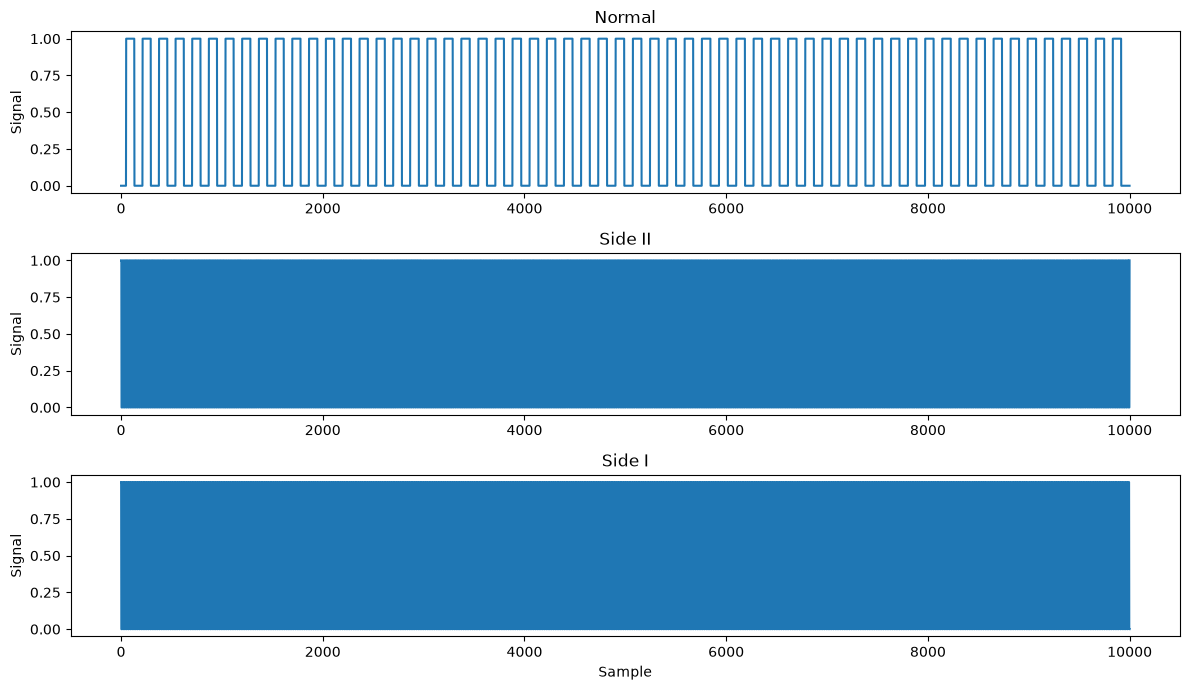

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7))

for ax, data, name in zip(
    axes,
    [train1, train2, train62],
    ["Normal", "Side II", "Side I"]
):
    ax.plot(data[speed_col])
    ax.set_title(name)
    ax.set_ylabel("Signal")

axes[-1].set_xlabel("Sample")
plt.tight_layout()
plt.show()

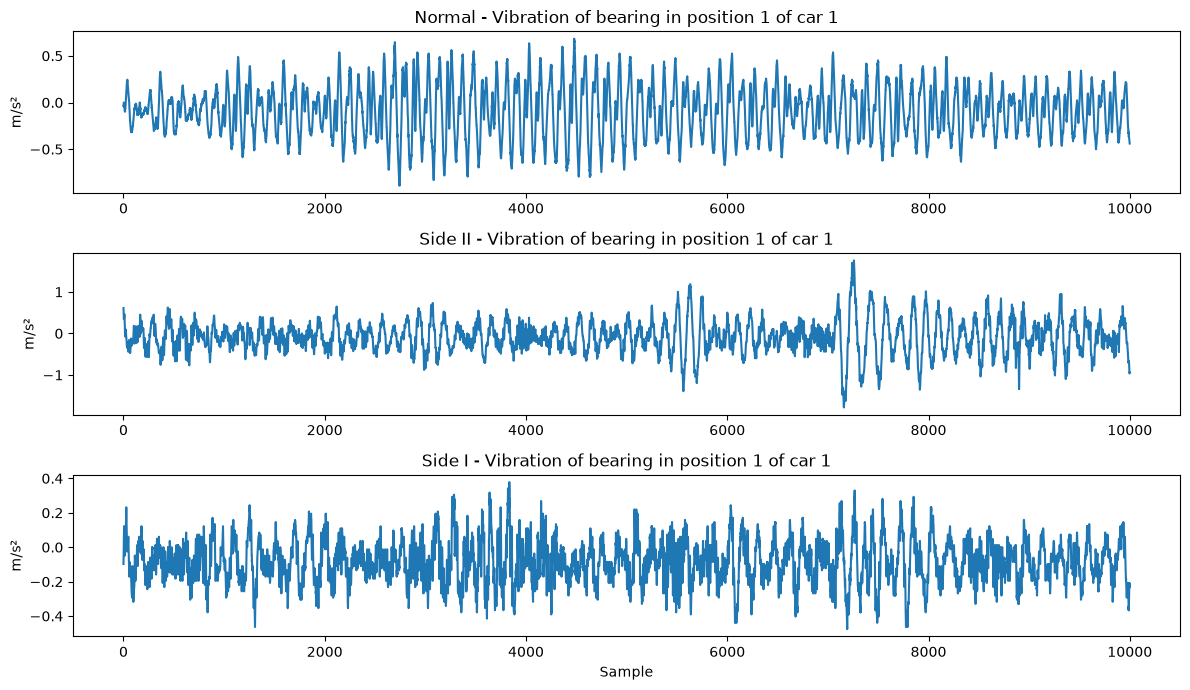

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7))

for ax, data, name in zip(
    axes,
    [train1, train2, train62],
    ["Normal", "Side II", "Side I"]
):
    ax.plot(data[vib_cols[0]])
    ax.set_title(f"{name} - {vib_cols[0]}")
    ax.set_ylabel("m/s²")

axes[-1].set_xlabel("Sample")
plt.tight_layout()
plt.show()

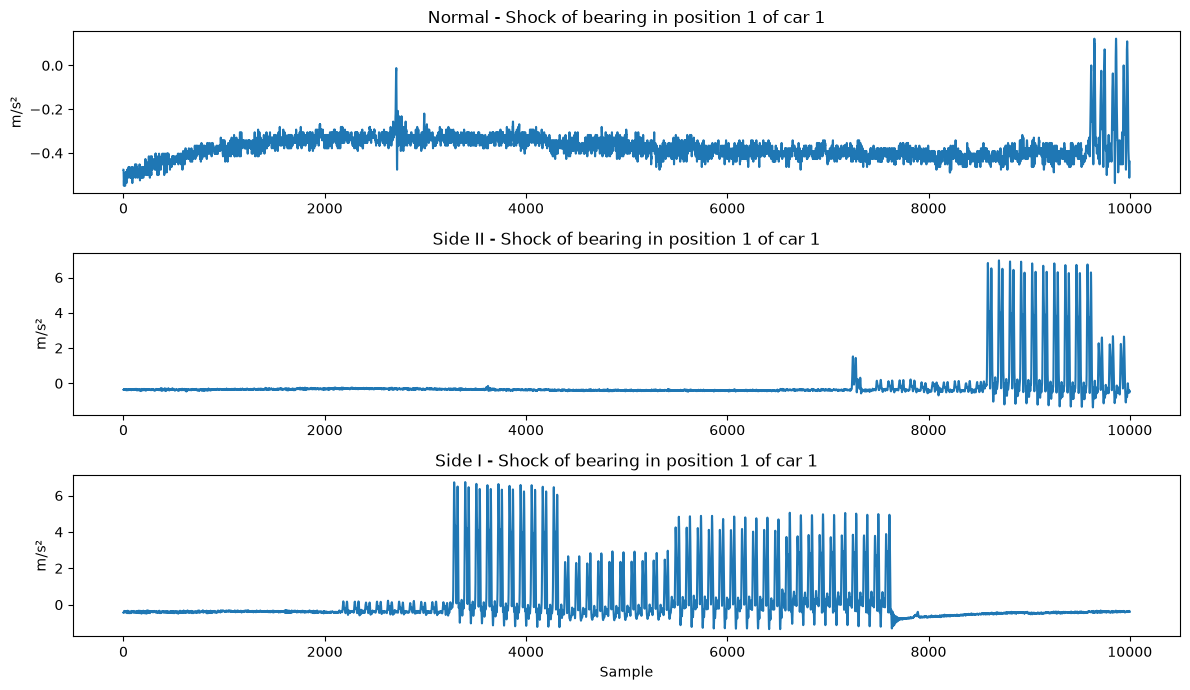

In [39]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7))

for ax, data, name in zip(
    axes,
    [train1, train2, train62],
    ["Normal", "Side II", "Side I"]
):
    ax.plot(data[shock_cols[0]])
    ax.set_title(f"{name} - {shock_cols[0]}")
    ax.set_ylabel("m/s²")

axes[-1].set_xlabel("Sample")
plt.tight_layout()
plt.show()

In [40]:
samples = {
    "Normal": train1,
    "Side II": train2,
    "Side I": train62
}

summary = pd.DataFrame({
    name: {
        "Vibration RMS": np.sqrt((data[vib_cols] ** 2).mean().mean()),
        "Shock RMS": np.sqrt((data[shock_cols] ** 2).mean().mean()),
        "Vibration std": data[vib_cols].stack().std(),
        "Shock std": data[shock_cols].stack().std()
    }
    for name, data in samples.items()
}).T

display(summary)

,Vibration RMS,Shock RMS,Vibration std,Shock std
Normal,0.188176,1.373510,0.183192,1.360665
Side II,0.943912,1.691678,0.943074,1.626097
Side I,0.561736,1.513436,0.560367,1.480222


In [41]:
side1_vib = [c for c in vib_cols if any(f"position {p}" in c.lower() for p in [1, 3, 5, 7])]
side2_vib = [c for c in vib_cols if any(f"position {p}" in c.lower() for p in [2, 4, 6, 8])]

print("Side I vibration channels:", len(side1_vib))
print("Side II vibration channels:", len(side2_vib))

Side I vibration channels: 32
Side II vibration channels: 32


In [42]:
side_summary = pd.DataFrame({
    name: {
        "Side I RMS": np.sqrt((data[side1_vib] ** 2).mean().mean()),
        "Side II RMS": np.sqrt((data[side2_vib] ** 2).mean().mean())
    }
    for name, data in samples.items()
}).T

display(side_summary)

,Side I RMS,Side II RMS
Normal,0.196928,0.178996
Side II,0.916845,0.970224
Side I,0.614989,0.502874
